# CQL vs Expert policy comparison

This notebook loads the per-query comparison CSV and the raw trajectory CSVs for both policies, builds a single pandas dataset, and visualizes the most important statistics.

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..")
EXPERT_CSV = ROOT / "outputs" / "trajectories_expert_test_results_dev_50.csv"
CQL_CSV = ROOT / "outputs" / "cql_dev_50.csv"
PER_QUERY_CSV = ROOT / "outputs" / "cql_vs_expert_dev_per_query.csv"

expert = pd.read_csv(EXPERT_CSV)
cql = pd.read_csv(CQL_CSV)
per_query = pd.read_csv(PER_QUERY_CSV)

numeric_cols = ["reward", "ndcg_before", "ndcg_after", "cost", "latency_ms", "cumulative_cost"]
for col in numeric_cols:
    if col in expert.columns:
        expert[col] = pd.to_numeric(expert[col], errors="coerce")
    if col in cql.columns:
        cql[col] = pd.to_numeric(cql[col], errors="coerce")

print(f"Expert rows: {len(expert):,}  |  CQL rows: {len(cql):,}  |  Per-query rows: {len(per_query):,}")

Expert rows: 74  |  CQL rows: 79  |  Per-query rows: 48


In [7]:
expert_df = pd.read_csv(EXPERT_CSV)
expert_df

,query_id,query,new_query,action_name,query_length,score_spread,score_entropy,step,rank_overlap,query_drift,...,ndcg_after,recall_before,recall_after,cost,latency_ms,cumulative_cost,cumulative_latency_ms,reward,terminal,timeout
0,1049368,who s sherlock holmes,who s sherlock holmes conan,PseudoRelevanceFeedback,4.0,0.692715,3.604299,1,0.588235,0.140968,...,0.000000,0.0,0.0,0.3,1310.185909,0.3,1310.185909,-0.103673,0,0
1,1049368,who s sherlock holmes,Sherlock Holmes is a fictional detective creat...,QueryReform,5.0,0.007163,3.911997,2,0.084746,0.227414,...,0.386853,0.0,1.0,1.0,26169.304609,1.3,27479.490519,0.201395,0,0
2,1049368,who s sherlock holmes,Sherlock Holmes is a fictional detective creat...,STOP,83.0,17.149378,0.567290,3,1.000000,0.227414,...,0.386853,1.0,1.0,0.0,0.000000,1.3,27479.490519,0.000000,1,0
3,262974,how long is a typical car loan?,how long is a typical car loan?,STOP,7.0,0.985524,3.012414,1,1.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,1,0
4,811852,what is the common name for jade,what is the common name for jade,STOP,7.0,1.402513,1.909746,1,1.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,264150,how long is mount beacon,how long is mount beacon,Rerank,5.0,1.590239,2.513241,1,1.000000,0.000000,...,0.500000,1.0,1.0,0.3,546.407938,0.3,546.407938,-0.340073,0,0
70,264150,how long is mount beacon,how long is mount beacon mountain,PseudoRelevanceFeedback,5.0,4.328683,2.652826,2,0.678571,0.086683,...,1.000000,1.0,1.0,0.3,1998.832703,0.6,2545.240641,0.873372,0,0
71,264150,how long is mount beacon,how long is mount beacon mountain,STOP,6.0,0.007235,3.911997,3,1.000000,0.086683,...,1.000000,1.0,1.0,0.0,0.000000,0.6,2545.240641,0.000000,1,0
72,1048995,who proposed the geocentric theory,who proposed the geocentric theory,STOP,5.0,2.586239,1.739849,1,1.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,1,0


In [8]:
cql_df = pd.read_csv(CQL_CSV)
cql_df

,query_id,query,new_query,action_name,query_length,score_spread,score_entropy,step,rank_overlap,query_drift,...,ndcg_after,recall_before,recall_after,cost,latency_ms,cumulative_cost,cumulative_latency_ms,reward,terminal,timeout
0,2,Androgen receptor define,NaN,STOP,3.0,0.890773,3.453895,0.000000,0.0,0.000000,...,0.00000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,True,False
1,524332,treating tension headaches without medication,NaN,Rerank,5.0,1.633734,2.377203,0.000000,0.0,0.000000,...,0.00000,0.0,0.0,0.3,372.598648,0.3,372.598648,-0.072420,False,False
2,524332,treating tension headaches without medication,NaN,STOP,5.0,2.264371,1.741800,0.333333,0.0,0.000000,...,0.00000,0.0,0.0,0.0,0.000000,0.3,372.598648,0.000000,True,False
3,1048642,what is paranoid sc,NaN,Rerank,4.0,0.642840,3.147437,0.000000,0.0,0.000000,...,0.00000,0.0,0.0,0.3,267.080545,0.3,267.080545,-0.068903,False,False
4,1048642,what is paranoid sc,NaN,STOP,4.0,2.201925,2.346658,0.333333,0.0,0.000000,...,0.00000,0.0,0.0,0.0,0.000000,0.3,267.080545,0.000000,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,1050923,what is milk thistle useful in treating?,NaN,Rerank,7.0,1.844486,2.023278,0.000000,0.0,0.000000,...,0.00000,0.0,0.0,0.3,246.169090,0.3,246.169090,-0.068206,False,False
75,1050923,what is milk thistle useful in treating?,NaN,STOP,7.0,1.618826,3.507072,0.333333,0.0,0.000000,...,0.00000,0.0,0.0,0.0,0.000000,0.3,246.169090,0.000000,True,False
76,526671,types of business entities,types of business entities llc,PseudoRelevanceFeedback,4.0,1.034750,3.102009,0.000000,0.0,0.000000,...,0.00000,0.0,0.0,0.3,1204.051256,0.3,1204.051256,-0.100135,False,False
77,526671,types of business entities llc,NaN,STOP,5.0,0.006409,3.912002,0.333333,0.0,0.094825,...,0.00000,0.0,0.0,0.0,0.000000,0.3,1204.051256,0.000000,True,False


In [9]:
# Build per-query aggregates from raw trajectory files (cost and reward only)
# NDCG gain already comes from the pre-computed per-query CSV.
expert_agg = expert.groupby("query_id", as_index=False).agg(
    expert_total_reward=("reward", "sum"),
    expert_total_cost=("cost", "sum"),
)
cql_agg = cql.groupby("query_id", as_index=False).agg(
    cql_total_reward=("reward", "sum"),
    cql_total_cost=("cost", "sum"),
)

df = per_query.merge(expert_agg, on="query_id", how="left").merge(cql_agg, on="query_id", how="left")

df["reward_diff"] = df["cql_reward"] - df["expert_reward"]
df["cost_diff"] = df["cql_total_cost"] - df["expert_total_cost"]
df["ndcg_gain_diff"] = df["cql_ndcg_gain"] - df["expert_ndcg_gain"]

print(f"Matched queries: {len(df)}")
df

Matched queries: 48


,query_id,expert_reward,cql_reward,expert_initial_ndcg,expert_final_ndcg,cql_initial_ndcg,cql_final_ndcg,expert_ndcg_gain,cql_ndcg_gain,expert_total_reward,expert_total_cost,cql_total_reward,cql_total_cost,reward_diff,cost_diff,ndcg_gain_diff
0,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
1,1288,0.526341,1.065587,0.430677,1.000000,0.430677,1.000000,0.569323,0.569323,0.526341,1.3,1.065587,0.3,0.539246,-1.0,0.000000
2,1576,0.000000,-0.073341,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.073341,0.3,-0.073341,0.3,0.000000
3,2235,0.000000,0.000000,0.430677,0.430677,0.430677,0.430677,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
4,262232,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
5,262974,0.000000,-0.072923,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.072923,0.3,-0.072923,0.3,0.000000
6,263670,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
7,263889,0.000000,-0.170384,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.170384,0.3,-0.170384,0.3,0.000000
8,264150,0.533299,0.000000,0.630930,1.000000,0.630930,0.630930,0.369070,0.000000,0.533299,0.6,0.000000,0.0,-0.533299,-0.6,-0.369070
9,264284,0.000000,-0.104194,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.104194,0.3,-0.104194,0.3,0.000000


## Action distribution by policy

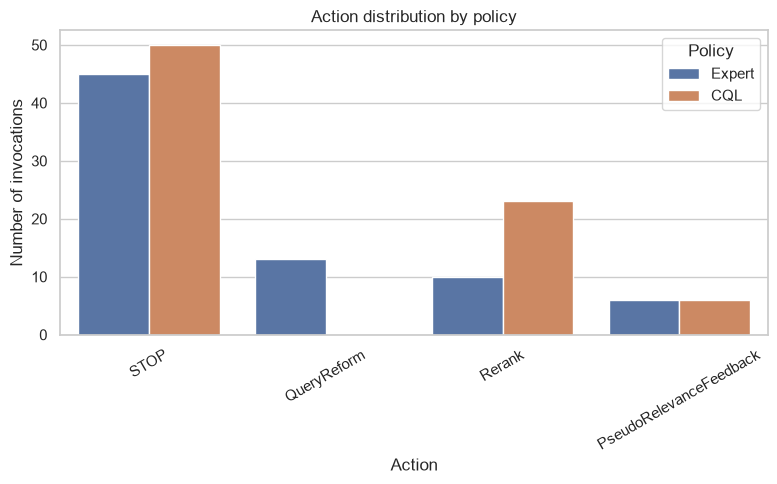

policy,CQL,Expert
action_name,,
PseudoRelevanceFeedback,6,6
QueryReform,0,13
Rerank,23,10
STOP,50,45


In [10]:
expert_actions = expert["action_name"].value_counts().reset_index()
expert_actions.columns = ["action_name", "count"]
expert_actions["policy"] = "Expert"

cql_actions = cql["action_name"].value_counts().reset_index()
cql_actions.columns = ["action_name", "count"]
cql_actions["policy"] = "CQL"

actions_df = pd.concat([expert_actions, cql_actions], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=actions_df, x="action_name", y="count", hue="policy", ax=ax)
ax.set_title("Action distribution by policy")
ax.set_xlabel("Action")
ax.set_ylabel("Number of invocations")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Policy", loc="upper right")
plt.tight_layout()
plt.show()

actions_df.pivot(index="action_name", columns="policy", values="count").fillna(0).astype(int)

## Total cost per query by policy

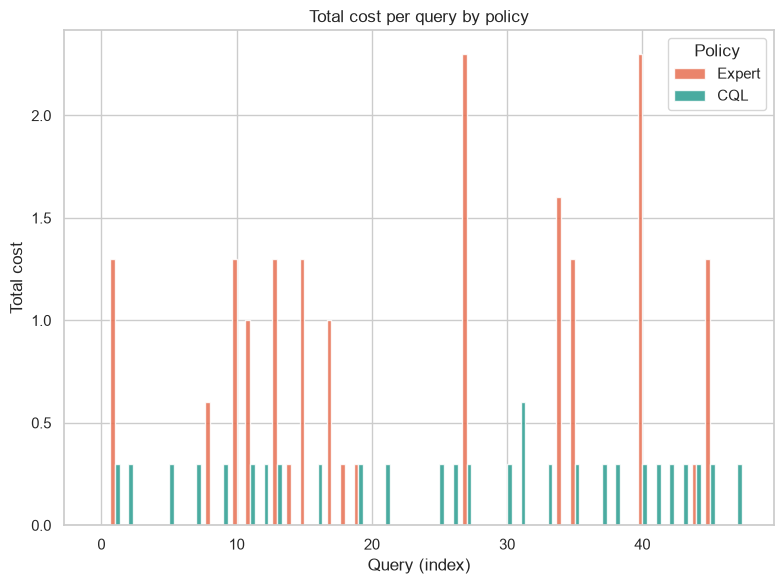

,Expert,CQL
Total cost,17.800000,8.400
Mean cost per query,0.370833,0.175


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(df))
width = 0.35

ax.bar(x - width / 2, df["expert_total_cost"], width, label="Expert", color="#e76f51", alpha=0.85)
ax.bar(x + width / 2, df["cql_total_cost"], width, label="CQL", color="#2a9d8f", alpha=0.85)

ax.set_xlabel("Query (index)")
ax.set_ylabel("Total cost")
ax.set_title("Total cost per query by policy")
ax.legend(title="Policy")
plt.tight_layout()
plt.show()

cost_summary = pd.DataFrame(
    {
        "Expert": [df["expert_total_cost"].sum(), df["expert_total_cost"].mean()],
        "CQL": [df["cql_total_cost"].sum(), df["cql_total_cost"].mean()],
    },
    index=["Total cost", "Mean cost per query"],
)
cost_summary

## NDCG@50 improvement per query by policy

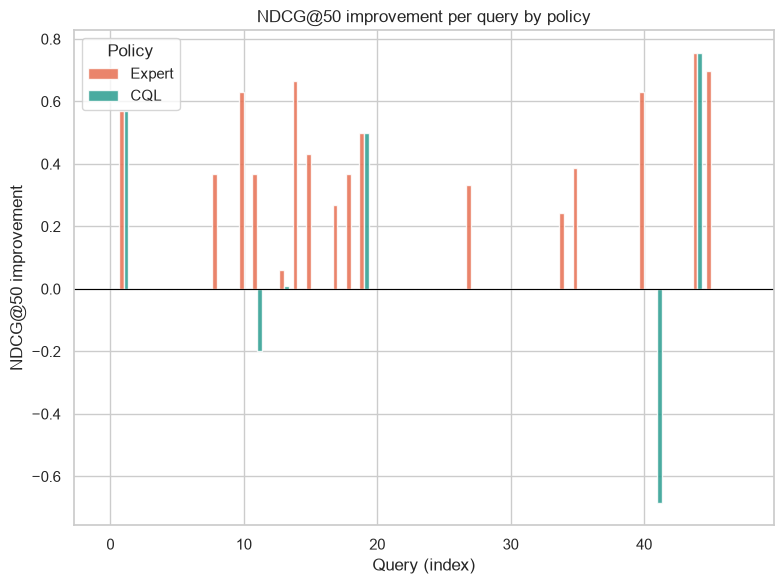

,Expert,CQL
Mean NDCG gain,0.151766,0.019802
Mean final NDCG,0.287615,0.155651


In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(df))
width = 0.35

ax.bar(x - width / 2, df["expert_ndcg_gain"], width, label="Expert", color="#e76f51", alpha=0.85)
ax.bar(x + width / 2, df["cql_ndcg_gain"], width, label="CQL", color="#2a9d8f", alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Query (index)")
ax.set_ylabel("NDCG@50 improvement")
ax.set_title("NDCG@50 improvement per query by policy")
ax.legend(title="Policy")
plt.tight_layout()
plt.show()

ndcg_summary = pd.DataFrame(
    {
        "Expert": [df["expert_ndcg_gain"].mean(), df["expert_final_ndcg"].mean()],
        "CQL": [df["cql_ndcg_gain"].mean(), df["cql_final_ndcg"].mean()],
    },
    index=["Mean NDCG gain", "Mean final NDCG"],
)
ndcg_summary

## Total reward per query by policy

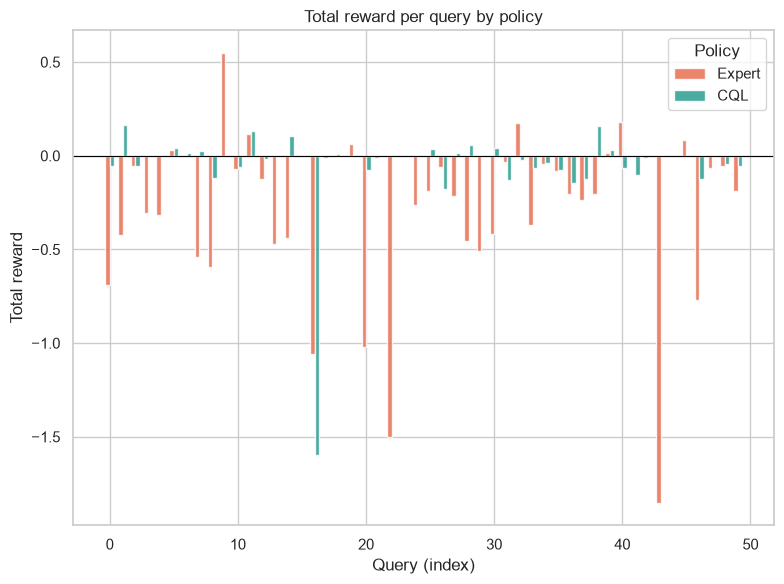

,Expert,CQL,Difference (CQL - Expert)
Mean reward per query,-0.252800,-0.046786,0.206014
Total reward,-12.640007,-2.339323,10.300685


In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(df))
width = 0.35

ax.bar(x - width / 2, df["expert_reward"], width, label="Expert", color="#e76f51", alpha=0.85)
ax.bar(x + width / 2, df["cql_reward"], width, label="CQL", color="#2a9d8f", alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Query (index)")
ax.set_ylabel("Total reward")
ax.set_title("Total reward per query by policy")
ax.legend(title="Policy")
plt.tight_layout()
plt.show()

reward_summary = pd.DataFrame(
    {
        "Expert": [df["expert_reward"].mean(), df["expert_reward"].sum()],
        "CQL": [df["cql_reward"].mean(), df["cql_reward"].sum()],
    },
    index=["Mean reward per query", "Total reward"],
)
reward_summary["Difference (CQL - Expert)"] = reward_summary["CQL"] - reward_summary["Expert"]
reward_summary

## Paired reward comparison: CQL vs Expert

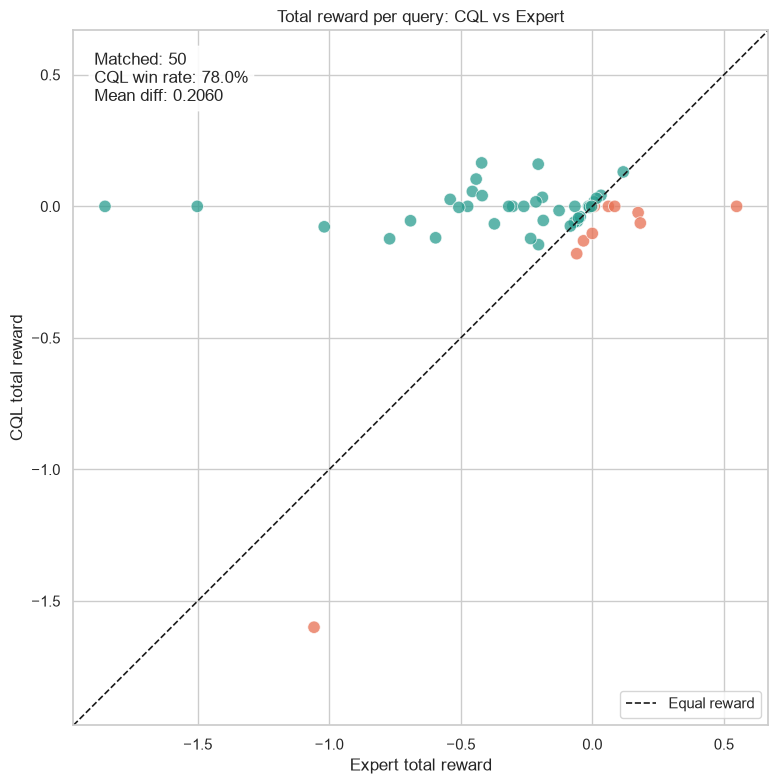

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))

wins = df["cql_reward"] > df["expert_reward"]
colors = np.where(wins, "#2a9d8f", "#e76f51")

ax.scatter(df["expert_reward"], df["cql_reward"], c=colors, s=80, alpha=0.75, edgecolor="white", linewidth=0.6)

lo = min(df["expert_reward"].min(), df["cql_reward"].min())
hi = max(df["expert_reward"].max(), df["cql_reward"].max())
pad = max((hi - lo) * 0.05, 0.01)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1.2, label="Equal reward")
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Expert total reward")
ax.set_ylabel("CQL total reward")
ax.set_title("Total reward per query: CQL vs Expert")
ax.legend(loc="lower right")

win_rate = wins.mean()
mean_diff = df["reward_diff"].mean()
ax.text(
    0.03,
    0.97,
    f"Matched: {len(df)}\nCQL win rate: {win_rate:.1%}\nMean diff: {mean_diff:.4f}",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.90},
)

plt.tight_layout()
plt.show()

In [25]:
output_path = ROOT / "outputs" / "cql_vs_expert_trec_dl_comparison_cleaned.csv"
df.to_csv(output_path, index=False)
print(f"Saved cleaned comparison dataset: {output_path}")

Saved cleaned comparison dataset: ..\outputs\cql_vs_expert_trec_dl_comparison_cleaned.csv
